# Robinhood App Review Analysis
Customer Feedback Intelligence Pipeline Project- BU CS 506

## 1. Packages

In [5]:
!pip install app-store-web-scraper
!pip install google-play-scraper
!pip install langdetect
!pip install contractions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=0b47e58890f665d4d9dab25f38ecf1cd7b4f84c1ae7f3d64db9d4a692c34192e
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00


In [6]:
# imports
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import contractions
from app_store_web_scraper import AppStoreEntry
from google_play_scraper import reviews, Sort
from langdetect import detect, LangDetectException
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

## 2. Data Collection

### Google Play Reviews Scraping

In [7]:
# Google Play store scraping
result, _ = reviews(
    'com.robinhood.android',
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=5000
)

gplay_reviews = []
for r in result:
    gplay_reviews.append({
        'review': r['content'],
        'rating': r['score'],
        'date': r['at'],
        'title': r['reviewId'],
        'country': 'google_play'
    })

gplay_df = pd.DataFrame(gplay_reviews)
print(f"Google Play reviews scraped: {len(gplay_df)}")

Google Play reviews scraped: 5000


### App Store Reviews Scraping

In [8]:
# App Store Reviews
all_reviews = []

# try catch to handle error when the reviews are unorganised data
for country in ['us', 'gb']:
    app = AppStoreEntry(app_id=938003185, country=country)
    count = 0
    try:
        for review in app.reviews():
            all_reviews.append({
                'review': review.content,
                'rating': review.rating,
                'date': review.date,
                'title': review.title,
                'country': country
            })
            count += 1
            if count >= 1000: #the apple api has a limit of 500 reviews (50 pages per country)
                break
    except TypeError:
        print(f"{country}: stopped early due to parsing error")
    print(f"{country}: scraped {count} reviews")
countries = ['us', 'gb']

app_store_df = pd.DataFrame(all_reviews)
app_store_df = app_store_df.drop_duplicates(subset='review')
print(f"App Store: {len(app_store_df)}")

# convert to pandas data frame and csv file
app_store_df.to_csv("robinhoods_reviews_app_store.csv")

us: scraped 500 reviews
gb: scraped 103 reviews
App Store: 590


### Combine Sources

In [9]:
def get_sentiment(rating): #for labeling sentiment based on rating
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

combined_df = pd.concat([app_store_df, gplay_df], ignore_index=True)
combined_df = combined_df.drop_duplicates(subset='review')
combined_df = combined_df.dropna(subset=['review'])
combined_df['sentiment'] = combined_df['rating'].apply(get_sentiment)
combined_df['source'] = combined_df['country'].apply(lambda x: 'App Store' if x in ['us', 'gb'] else 'Google Play')
combined_df = combined_df.reset_index(drop=True)

# discard too short (20 then 30)
combined_df['review_length'] = combined_df['review'].apply(len)
combined_df = combined_df[combined_df['review_length'] > 30]

print(f"App Store: {len(app_store_df)}")
print(f"Google Play: {len(gplay_df)}")
print(f"Total combined reviews: {len(combined_df)}")
combined_df['rating'].value_counts().sort_index()

App Store: 590
Google Play: 5000
Total combined reviews: 3999


,count
rating,
1,2032
2,299
3,304
4,332
5,1032


## 3. EDA

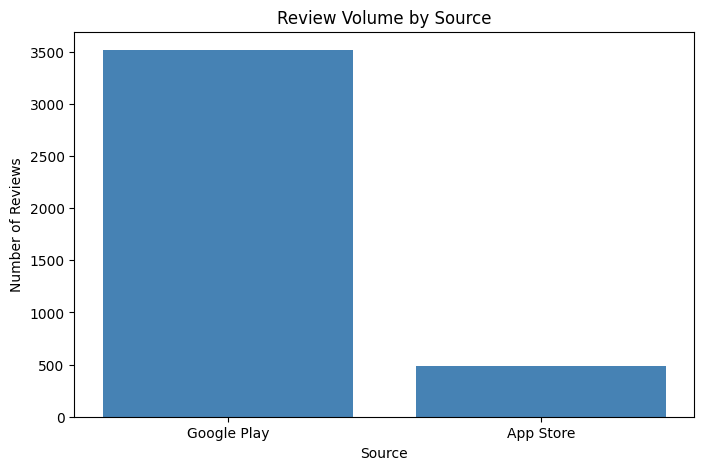

In [10]:
# Review volume by source
source_counts = combined_df['source'].value_counts().rename('count').to_frame()
all_sources = pd.DataFrame({'source': ['Google Play', 'App Store']})
merged_counts = all_sources.set_index('source').merge(source_counts, left_index=True, right_index=True, how='left').fillna(0)

plt.figure(figsize=(8, 5))
plt.bar(merged_counts.index, merged_counts['count'], color='steelblue')
plt.xlabel('Source')
plt.ylabel('Number of Reviews')
plt.title('Review Volume by Source')
plt.show()

Note: the distribution of the data is heavily skewed toward 1 stars and 5 stars fewer 2s, 3s and 4s. People either didn't like the app or they really liked it, basically few in betweens.

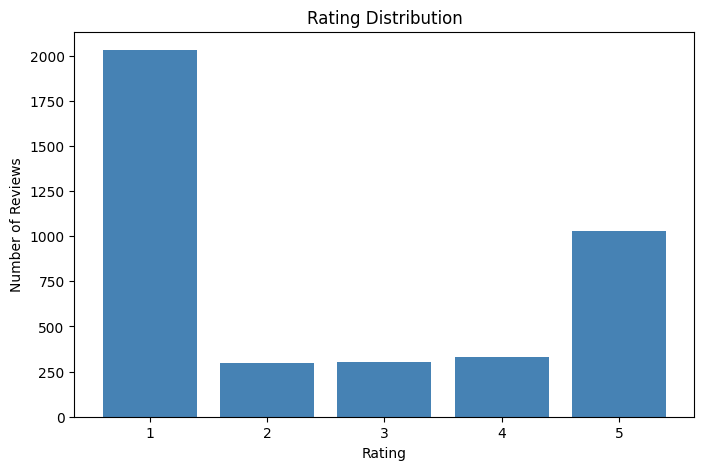

In [11]:
# counting the number of ratings for each type of rating
freq = combined_df['rating'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(freq.index, freq.values, color='steelblue')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Rating Distribution')
plt.show()

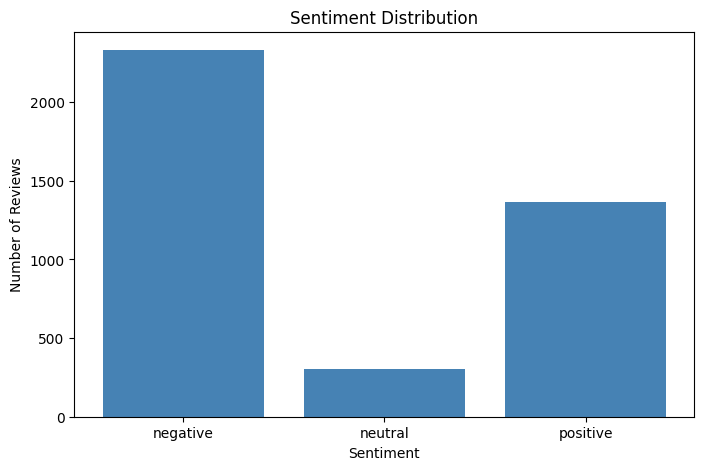

In [12]:
freq = combined_df['sentiment'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(freq.index, freq.values, color='steelblue')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.title('Sentiment Distribution')
plt.show()

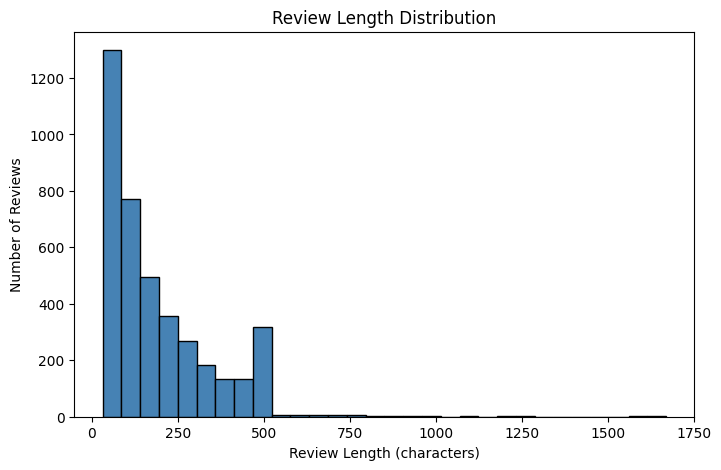

In [13]:
# Review length distribution
plt.figure(figsize=(8, 5))
plt.hist(combined_df['review_length'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Reviews')
plt.title('Review Length Distribution')
plt.show()

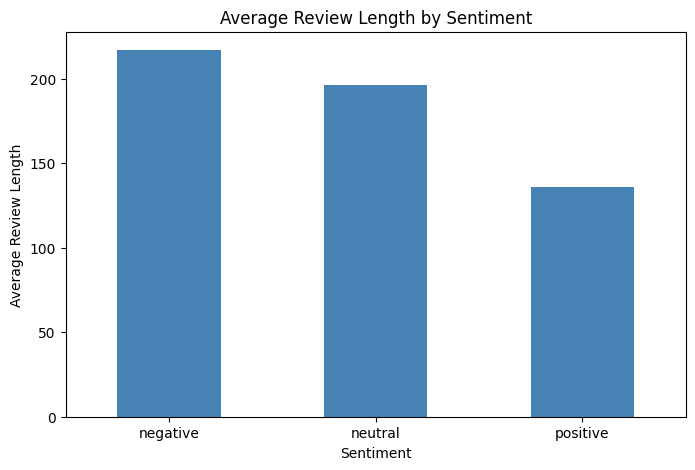

In [14]:
# Avg review length by sentiment
combined_df.groupby('sentiment')['review_length'].mean().plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.xlabel('Sentiment')
plt.ylabel('Average Review Length')
plt.title('Average Review Length by Sentiment')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_13729/1721647885.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  combined_df.groupby(combined_df['date'].dt.to_period('W'))['rating'].mean().plot(figsize=(10, 5), color='steelblue')


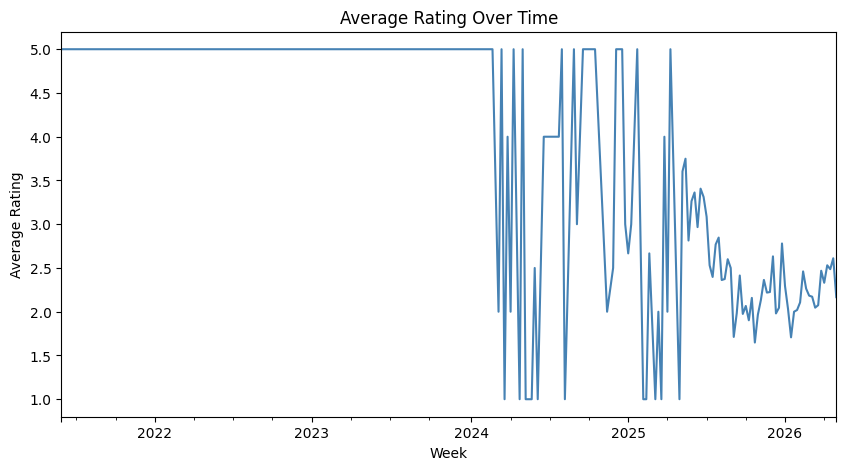

In [15]:
combined_df['date'] = pd.to_datetime(combined_df['date'], utc=True)
combined_df.groupby(combined_df['date'].dt.to_period('W'))['rating'].mean().plot(figsize=(10, 5), color='steelblue')
plt.xlabel('Week')
plt.ylabel('Average Rating')
plt.title('Average Rating Over Time')
plt.show()

- The spikes are misleading because a single 5-star review in a week with no other reviews gives an average of 5.0, which looks dramatic but means nothing.


/tmp/ipykernel_13729/2381793897.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  combined_df.groupby(combined_df['date'].dt.to_period('W'))['rating'].count().plot(figsize=(10, 5), color='steelblue')


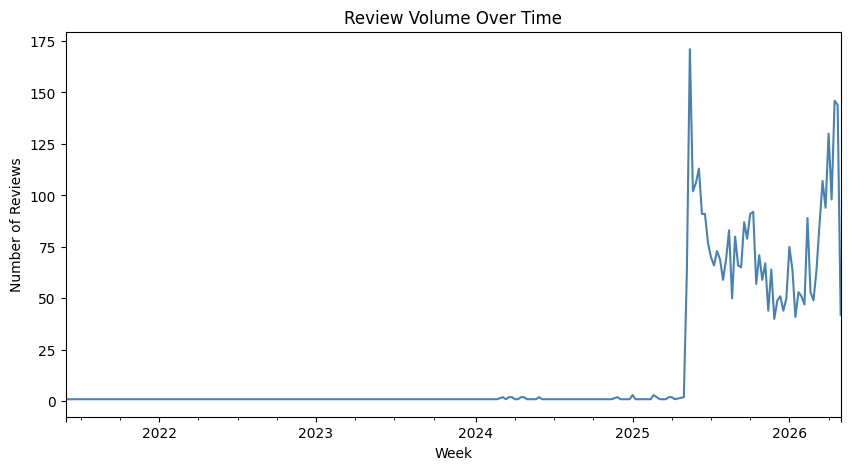

In [16]:
combined_df.groupby(combined_df['date'].dt.to_period('W'))['rating'].count().plot(figsize=(10, 5), color='steelblue')
plt.xlabel('Week')
plt.ylabel('Number of Reviews')
plt.title('Review Volume Over Time')
plt.show()

/tmp/ipykernel_13729/235398449.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  gplay_only.groupby(gplay_only['date'].dt.to_period('W'))['rating'].mean().plot(figsize=(10, 5), color='steelblue')


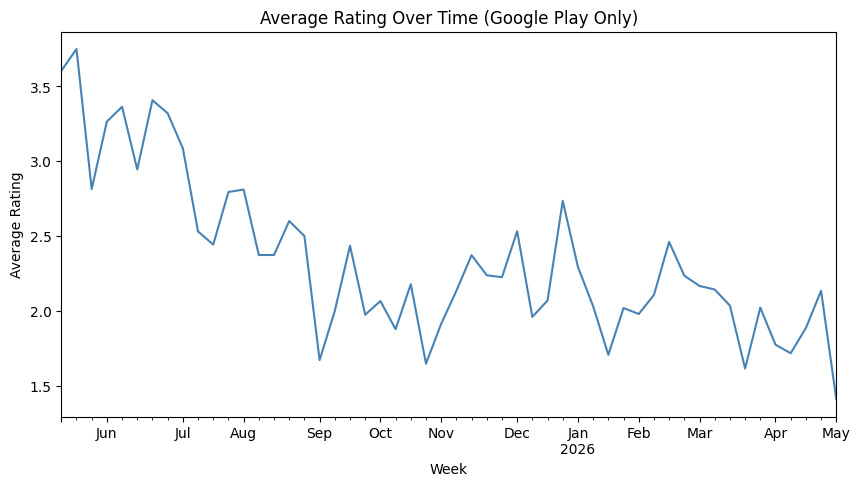

In [17]:
# Average rating over time (Google Play only)
# More reliable - consistent volume of 80-250 reviews per week
gplay_only = combined_df[combined_df['source'] == 'Google Play']
gplay_only.groupby(gplay_only['date'].dt.to_period('W'))['rating'].mean().plot(figsize=(10, 5), color='steelblue')
plt.xlabel('Week')
plt.ylabel('Average Rating')
plt.title('Average Rating Over Time (Google Play Only)')
plt.show()

## 4. Data Cleaning

In [18]:
# Remove the non-English reviews

# Short reviews kept since langdetect seems unreliable on very short

def is_english(text):
    try:
        if len(str(text)) < 20:
            return True
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False

before = len(combined_df)
combined_df = combined_df[combined_df['review'].apply(is_english)].reset_index(drop=True)
print(f'Removed {before - len(combined_df)} non-English reviews')
print(f'Remaining: {len(combined_df)}')

Removed 42 non-English reviews
Remaining: 3957


In [19]:
# realized i needed to clean the data- terrible clusters with raw reviews, all numbers showing up
# added method for deling with contractions

def clean_text(text):
    text = contractions.fix(text) #
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 2]

    return " ".join(tokens)

combined_df['clean_review'] = combined_df['review'].apply(clean_text)
combined_df = combined_df.reset_index(drop=True)
combined_df.to_csv('robinhood_reviews_cleaned.csv', index=False)
print(f'Cleaned dataset saved: {len(combined_df)} reviews')

combined_df.head(3)[['review', 'clean_review']]

Cleaned dataset saved: 3957 reviews


,review,clean_review
0,They don’t have customer support at all. I hav...,they not have customer support all have been s...
1,Terrible. Placed a market order after hours an...,terrible placed market order after hours and n...
2,I am unable to withdraw money out from robinho...,unable withdraw money out from robinhood app t...


## 5. Feature Extraction (TF-IDF)

In [20]:
# TF-IDF Feature Extraction
# To keep the pipeline scalable and reusable for predictions from other apps
# filter to negative reviews
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=list(ENGLISH_STOP_WORDS),
    min_df=5,
    max_df=1.0,
    ngram_range=(1, 1),
    use_idf=False,
    smooth_idf=True,
    sublinear_tf=False
)

tfidf.fit(combined_df['clean_review'])

X = tfidf.fit_transform(combined_df["clean_review"])

print(f"TF-IDF matrix shape: {X.shape}")
print(f"Vocabulary size: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape: (3957, 1649)
Vocabulary size: 1649


In [21]:
# used from countwordsfree.com
stops = {
        'able', 'about', 'above', 'abroad', 'according', 'accordingly', 'across',
    'actually', 'after', 'afterwards', 'again', 'against', 'ago', 'ahead',
    "ain't", 'all', 'allow', 'allows', 'almost', 'alone', 'along', 'already',
    'also', 'although', 'always', 'am', 'amid', 'among', 'an', 'and', 'another',
    'any', 'anybody', 'anyhow', 'anyone', 'anything', 'anyway', 'anywhere',
    'apart', 'appear', 'appreciate', 'appropriate', 'are', 'around', 'as',
    'ask', 'asking', 'at', 'available', 'away', 'back', 'be', 'became',
    'because', 'become', 'becomes', 'been', 'before', 'being', 'below',
    'beside', 'besides', 'best', 'better', 'between', 'beyond', 'both',
    'brief', 'but', 'by', 'came', 'can', 'cannot', 'cant', 'cause',
    'certain', 'certainly', 'changes', 'clearly', 'come', 'comes',
    'concerning', 'consider', 'contain', 'contains', 'could', 'course',
    'currently', 'did', 'different', 'do', 'does', 'doing', 'done',
    'down', 'during', 'each', 'eg', 'eight', 'either', 'else',
    'elsewhere', 'enough', 'entirely', 'especially', 'etc', 'even',
    'ever', 'every', 'everyone', 'everything', 'everywhere', 'example',
    'except', 'far', 'few', 'first', 'five', 'followed', 'following',
    'for', 'former', 'formerly', 'forth', 'found', 'four', 'from',
    'further', 'get', 'gets', 'getting', 'given', 'gives', 'go',
    'goes', 'going', 'gone', 'got', 'had', 'has', 'have', 'having',
    'he', 'help', 'her', 'here', 'hers', 'herself', 'him', 'himself',
    'his', 'how', 'however', 'i', 'if', 'in', 'indeed', 'into', 'is',
    'it', 'its', 'itself', 'just', 'keep', 'keeps', 'know', 'known',
    'last', 'later', 'least', 'less', 'let', 'like', 'likely', 'little',
    'look', 'made', 'make', 'many', 'may', 'maybe', 'me', 'mean',
    'meanwhile', 'merely', 'might', 'more', 'moreover', 'most',
    'mostly', 'much', 'must', 'my', 'myself', 'name', 'near',
    'nearly', 'necessary', 'need', 'neither', 'never', 'new',
    'next', 'nine', 'no', 'nobody', 'none', 'nor', 'not',
    'nothing', 'now', 'nowhere', 'of', 'off', 'often', 'on',
    'once', 'one', 'only', 'onto', 'or', 'other', 'others',
    'otherwise', 'our', 'ours', 'ourselves', 'out', 'outside',
    'over', 'own', 'particular', 'particularly', 'past', 'perhaps',
    'please', 'possible', 'probably', 'provided', 'provides',
    'quite', 'rather', 'really', 'recent', 'recently', 'regarding',
    'relatively', 'same', 'say', 'saying', 'says', 'second',
    'see', 'seem', 'seemed', 'seems', 'seen', 'self', 'several',
    'shall', 'she', 'should', 'since', 'six', 'so', 'some',
    'somebody', 'someone', 'something', 'sometimes', 'somewhat',
    'somewhere', 'soon', 'sorry', 'still', 'such', 'sure',
    'take', 'taken', 'taking', 'tell', 'than', 'that', 'the',
    'their', 'theirs', 'them', 'themselves', 'then', 'there',
    'therefore', 'these', 'they', 'thing', 'things', 'think',
    'this', 'those', 'though', 'three', 'through', 'thus',
    'to', 'together', 'too', 'took', 'toward', 'try',
    'trying', 'two', 'under', 'until', 'up', 'upon', 'us',
    'use', 'used', 'using', 'usually', 'very', 'via',
    'want', 'was', 'way', 'we', 'well', 'were', 'what',
    'when', 'where', 'which', 'while', 'who', 'whom',
    'why', 'will', 'with', 'within', 'without', 'would',
    'yes', 'yet', 'you', 'your', 'yours', 'yourself',
    'yourselves', 'robinhood', 'stock', 'account', 'stocks', 'app', 'investing', 'investment',
    'trading', 'market', 'platform'
}

all_stopwords = list(ENGLISH_STOP_WORDS.union(stops))
print(f'Total stopwords: {len(all_stopwords)}')

# Final TF-IDF
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=all_stopwords,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True,
    max_features=2000
)

X = tfidf.fit_transform(combined_df['clean_review'])
print(f'TF-IDF matrix shape: {X.shape}')
print(f'Vocabulary size: {len(tfidf.get_feature_names_out())}')

Total stopwords: 448


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ain'] not in stop_words.
  warnings.warn(


TF-IDF matrix shape: (3957, 1862)
Vocabulary size: 1862


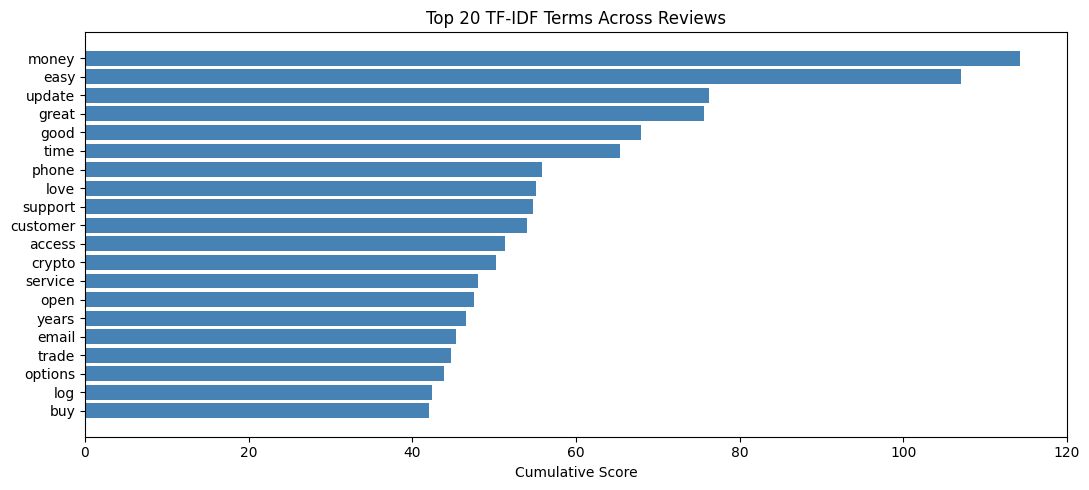

In [ ]:
# Visualize top terms across all reviews
feature_names = tfidf.get_feature_names_out()
term_scores = np.asarray(X.sum(axis=0)).flatten()
top_idx = term_scores.argsort()[-20:][::-1]

plt.figure(figsize=(11, 5))
plt.barh([feature_names[i] for i in top_idx][::-1],
         [term_scores[i] for i in top_idx][::-1], color='steelblue')
plt.title('Top 20 TF-IDF Terms Across Reviews')
plt.xlabel('Cumulative Score')
plt.tight_layout()
# plt.savefig('tfidf_top_terms.png', bbox_inches='tight')
plt.show()

## 6. Dimensionality Reduction (LSA)

In [24]:
# Apply LSA using truncated SVD to reduce the TF-IDF feature space into 20 dimensions for clustering
svd = TruncatedSVD(n_components=20, n_iter=15, random_state=42)

lsa = make_pipeline(svd, Normalizer(copy=False))
X_reduced = lsa.fit_transform(X)

print(f'matrix shape: {X_reduced.shape}')

matrix shape: (3957, 20)


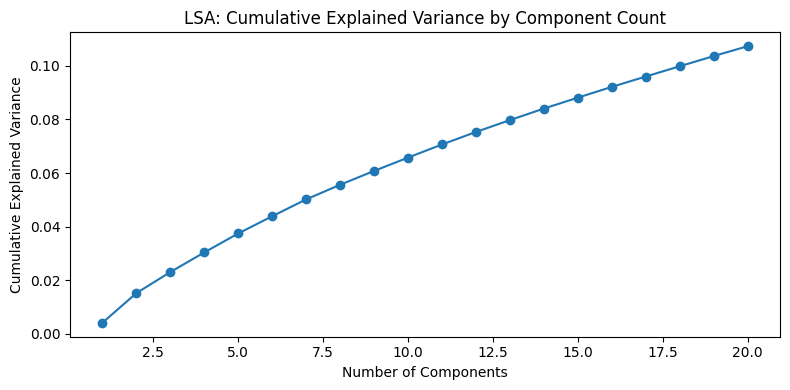

Total variance explained by 50 components: 10.7%


In [25]:
explained_var = svd.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('LSA: Cumulative Explained Variance by Component Count')
plt.tight_layout()
plt.savefig('lsa_variance.png', bbox_inches='tight')
plt.show()
print(f'Total variance explained by 50 components: {explained_var[-1]:.1%}')

## 7. Clustering with K-means

In [26]:
# filtre to negative reviews before clustering.
neg_df = combined_df[combined_df['sentiment'] == 'negative'].copy().reset_index(drop=True)
X_neg = tfidf.transform(neg_df['clean_review'])
X_neg_reduced = lsa.transform(X_neg)
print(f'matrix shape: {X_neg_reduced.shape}')



matrix shape: (2315, 20)


k=3: silhouette=0.1090
k=4: silhouette=0.1322
k=5: silhouette=0.1610
k=6: silhouette=0.1691
k=7: silhouette=0.1770
k=8: silhouette=0.1954
k=9: silhouette=0.2037
k=10: silhouette=0.2149

Best k: 10


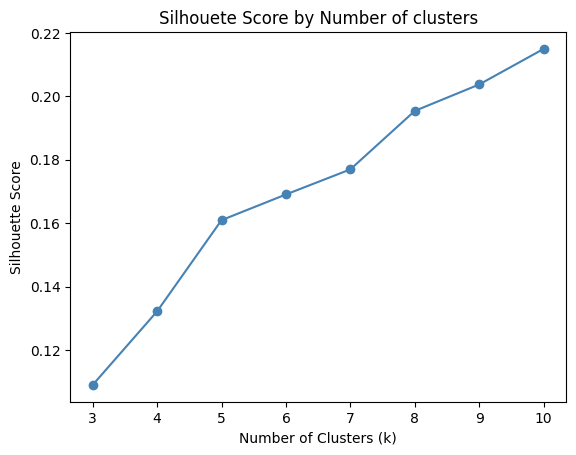

In [27]:
# silhouette score to find the best k
sil_scores = {}
for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++')
    labels = km.fit_predict(X_neg_reduced)
    score = silhouette_score(X_neg_reduced, labels, random_state=42)
    sil_scores[k] = score
    print(f'k={k}: silhouette={score:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest k: {best_k}')

plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouete Score by Number of clusters')
plt.show()

K-Means makes spherical clusters but text data is high-dimensional, 1000 feature, and sparse, which explains the low scores.

In [28]:
# Final K-means with k=5
km_final = KMeans(n_clusters=5, random_state=42, n_init=10, init='k-means++')
cluster_labels_arr = km_final.fit_predict(X_neg_reduced)
neg_df['cluster'] = cluster_labels_arr

# Reconstruct top terms by projecting cluster centers back to vocabulary space
original_centers = km_final.cluster_centers_.dot(svd.components_)

# top terms per cluster
print('Top terms per cluster:\n')

for i in range(5):
    top_idx = original_centers[i].argsort()[-12:][::-1]
    top_terms = [feature_names[j] for j in top_idx]
    print(f'Cluster {i}: {top_terms}')

Top terms per cluster:

Cluster 0: ['support', 'email', 'phone', 'log', 'access', 'old', 'number', 'password', 'customer support', 'tried', 'contact', 'phone number']
Cluster 1: ['money', 'withdraw', 'bank', 'company', 'withdraw money', 'scam', 'transfer', 'sell', 'buy', 'making', 'days', 'people']
Cluster 2: ['crypto', 'time', 'trade', 'buy', 'options', 'years', 'open', 'sell', 'card', 'gold', 'price', 'day']
Cluster 3: ['service', 'customer', 'customer service', 'money', 'terrible', 'horrible', 'years', 'support', 'customer support', 'experience', 'issues', 'number']
Cluster 4: ['update', 'email', 'telling', 'update update', 'telling update', 'update email', 'version', 'work', 'ira', 'fix', 'open', 'address']


In [33]:
# # Sample reviews per cluster for manual validation
# def print_sample_reviews(df, cluster_num, n=3):
#     label = cluster_label_map[cluster_num]
#     print(f'Cluster {cluster_num}: {label}')
#     samples = df[df['cluster'] == cluster_num]['review'].sample(n, random_state=42)
#     for i, review in enumerate(samples, 1):
#         print(f'{i}. {review[:200]}\n')

# for c in range(5):
#     print_sample_reviews(neg_df, c)
#     print()

First attempt: realized cleaning with regex is needed because produced numbers in the clusters that isnt necesary then. i analyzed and decided to keep adding to the stop words:
```
Cluster 0: ['robinhood', 'money', 'trading', 'good', 'stock', 'stocks', 'like', 'market', 'best', 'time']
Cluster 1: ['great', 'great app', 'app', 'easy', 'investing', 'platform', 'works', 'app great', 'investment', 'trading']
Cluster 2: ['account', 'cant', 'get', 'customer', 'phone', 'money', 'support', 'email', 'service', 'customer service']
Cluster 3: ['app', 'update', 'open', 'use', 'love', 'keeps', 'robinhood', 'love app', 'good', 'fix']
Cluster 4: ['easy', 'easy use', 'use', 'app easy', 'app', 'great', 'good', 'love', 'use great', 'great app']
```

In [31]:
cluster_label = " / ".join(top_terms[:3])

In [61]:
# Stretch: Instead of manually writing cluster labels or using raw top-term strings, I can use Gemini API which reads each cluster's top 12 terms and returns a brief descriptive label.

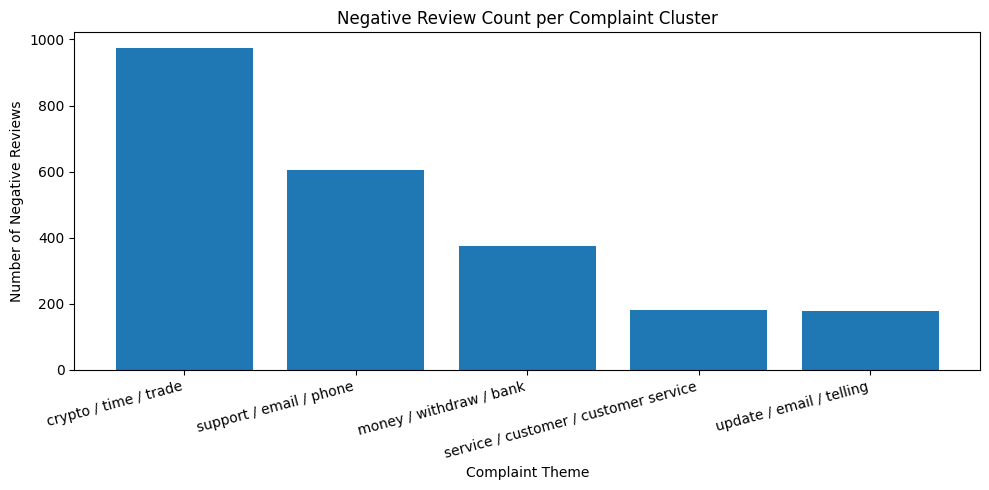

In [ ]:
# Manually label clusters based on top terms
# cluster_label_map = {
#     0: 'General Trading Experience',
#     1: 'Positive Reviews', #more general
#     2: 'Customer Support Complaints',
#     3: 'App Technical Issues',
#     4: 'Ease of Use'
# }

# feature_names = tfidf.get_feature_names_out()


cluster_label_map = {}

for i in range(5):
    top_idx = original_centers[i].argsort()[-12:][::-1]
    top_terms = [feature_names[j] for j in top_idx]
    cluster_label_map[i] = " / ".join(top_terms[:3])

neg_df["cluster_label"] = neg_df["cluster"].map(cluster_label_map)

combined_df.loc[combined_df["sentiment"] == "negative", "cluster"] = cluster_labels_arr
combined_df.loc[combined_df["sentiment"] == "negative", "cluster_label"] = (
    combined_df.loc[combined_df["sentiment"] == "negative", "cluster"].map(cluster_label_map)
)

cluster_counts = neg_df["cluster_label"].value_counts()

# cluster_counts = neg_df["cluster"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel("Complaint Theme")
plt.ylabel("Number of Negative Reviews")
plt.title("Negative Review Count per Complaint Cluster")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
# plt.savefig("cluster_frequency.png", bbox_inches="tight")
plt.show()


## 8. Sentiment Classification

In [50]:
# Train-test split of data
X_train, X_test, y_train, y_test = train_test_split(
    X, combined_df['sentiment'], test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Class distribution in train:')
print(y_train.value_counts())

Train: (3165, 1862), Test: (792, 1862)
Class distribution in train:
sentiment
negative    1844
positive    1072
neutral      249
Name: count, dtype: int64


In [51]:
# Logistic Regression with class balancing
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=1.0)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print('Logistic Regression:')
print(classification_report(y_test, lr_preds, zero_division=0))
print(f'Accuracy: {accuracy_score(y_test, lr_preds):.3f}')

cv_scores = cross_val_score(lr, X, combined_df['sentiment'], cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')

Logistic Regression:
              precision    recall  f1-score   support

    negative       0.83      0.79      0.81       471
     neutral       0.11      0.23      0.15        52
    positive       0.76      0.68      0.72       269

    accuracy                           0.71       792
   macro avg       0.57      0.56      0.56       792
weighted avg       0.76      0.71      0.73       792

Accuracy: 0.712
5-Fold CV Accuracy: 0.718 +/- 0.035


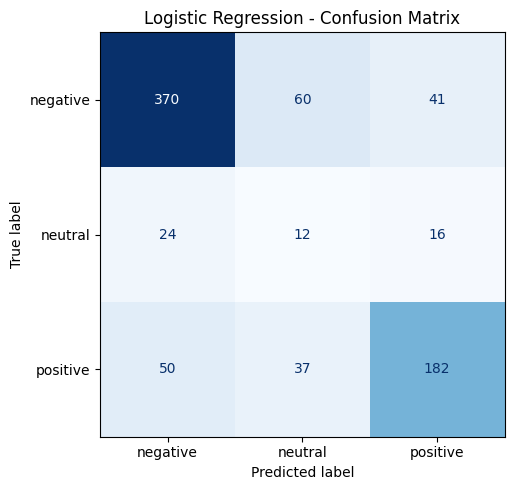

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, lr_preds, labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['negative', 'neutral', 'positive'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
# plt.savefig('confusion_matrix_lr.png', bbox_inches='tight')
plt.show()

#9. Model comparison

In [53]:
models = {
    'Logistic Regression': lr,
    'Complement Naive Bayes': ComplementNB(alpha=0.1),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=15, random_state=42,
        class_weight='balanced', min_samples_leaf=5
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'Test Accuracy': acc,
        'CV Mean': cv.mean(),
        'CV Std': cv.std(),
        'Predictions': preds
    }

    print(f'{name}: test={acc:.3f} | CV={cv.mean():.3f} +/- {cv.std():.3f}')

results_df = pd.DataFrame(results).T[['Test Accuracy', 'CV Mean', 'CV Std']]
print()
print(results_df.round(3))

Logistic Regression: test=0.712 | CV=0.722 +/- 0.014
Complement Naive Bayes: test=0.742 | CV=0.752 +/- 0.011
Decision Tree: test=0.383 | CV=0.578 +/- 0.121

                       Test Accuracy   CV Mean    CV Std
Logistic Regression         0.712121  0.721959  0.014024
Complement Naive Bayes      0.742424  0.751659  0.010872
Decision Tree               0.382576  0.577883  0.120534


In [54]:
# viusalize
model_names = list(results.keys())
test_accs = [results[m]['Test Accuracy'] for m in model_names]
cv_means = [results[m]['CV Mean'] for m in model_names]
cv_stds = [results[m]['CV Std'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

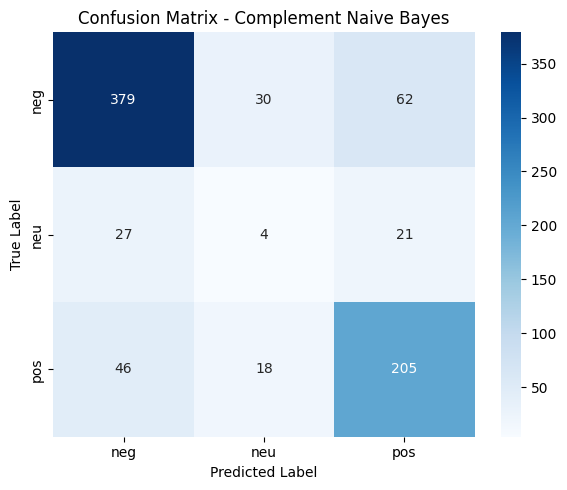

In [ ]:
best_model_name = max(results, key=lambda m: results[m]['CV Mean'])
best_preds = results[best_model_name]['Predictions']

cm2 = confusion_matrix(
    y_test, best_preds,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['neg', 'neu', 'pos'],
    yticklabels=['neg', 'neu', 'pos']
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
# plt.savefig('confusion_matrix_best_model.png', bbox_inches='tight')
plt.show()



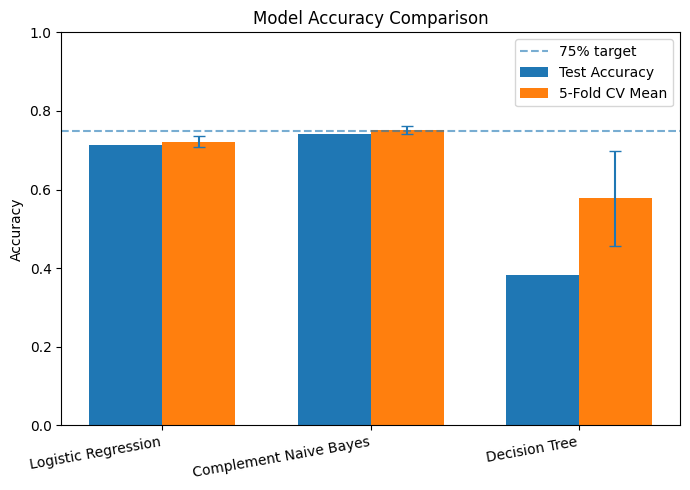

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(x - width/2, test_accs, width, label='Test Accuracy')
plt.bar(x + width/2, cv_means, width, label='5-Fold CV Mean')

plt.errorbar(x + width/2, cv_means, yerr=cv_stds, fmt='none', capsize=4)

plt.axhline(y=0.75, linestyle='--', alpha=0.6, label='75% target')

plt.xticks(x, model_names, rotation=10, ha='right')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.ylim(0, 1)

plt.tight_layout()
# plt.savefig('model_accuracy.png', bbox_inches='tight')
plt.show()

# 10. Competitor Analysis with Fidelity, Charles Schwab and Vanguard

In [57]:
# Scrape competitor apps from Google Play
competitors = {
    'Fidelity':       'com.fidelity.android',
    'Charles Schwab': 'com.schwab.mobile',
    'Vanguard':       'com.vanguard',
}

competitor_dfs = {}

for name, id in competitors.items():
    try:
        result, _ = reviews(
            id,
            lang='en',
            country='us',
            sort=Sort.NEWEST,
            count=2000
        )


        rows = []
        for r in result:
            rows.append({
                'review': r['content'],
                'rating': r['score'],
                'date': r['at'],
                'app': name
            })

        df = pd.DataFrame(rows)
        df = df.dropna(subset=['review'])
        df['clean_review'] = df['review'].apply(clean_text)
        df['sentiment'] = df['rating'].apply(get_sentiment)
        competitor_dfs[name] = df

        print(f'{name}: {len(df)} reviews scraped')

    except Exception as e:
        print(f'{name}: failed - {e}')
        competitor_dfs[name] = pd.DataFrame()

Fidelity: 2000 reviews scraped
Charles Schwab: 2000 reviews scraped
Vanguard: 2000 reviews scraped


In [58]:
# Apply the trained Robinhood pipeline to competitor reviews
competitor_results = {}

for name, df in competitor_dfs.items():
    if df.empty:
        continue
    X_comp = tfidf.transform(df['clean_review'])
    preds = lr.predict(X_comp)
    proba = lr.predict_proba(X_comp)

    df['predicted_sentiment'] = preds
    df['confidence'] = proba.max(axis=1)

    competitor_results[name] = {
        'avg_rating': df['rating'].mean(),
        'neg_rate': (preds == 'negative').mean(),
        'pos_rate': (preds == 'positive').mean(),
        'n_reviews': len(df)
    }

# Add Robinhood for reference
rh_preds = lr.predict(X)
competitor_results['Robinhood'] = {
    'avg_rating': combined_df['rating'].mean(),
    'neg_rate': (rh_preds == 'negative').mean(),
    'pos_rate': (rh_preds == 'positive').mean(),
    'n_reviews': len(combined_df)
}

comp_df = pd.DataFrame(competitor_results).T
print(comp_df.round(3).to_string())

                avg_rating  neg_rate  pos_rate  n_reviews
Fidelity             1.746     0.598     0.210     2000.0
Charles Schwab       2.096     0.564     0.250     2000.0
Vanguard             2.402     0.486     0.324     2000.0
Robinhood            2.500     0.549     0.309     3957.0


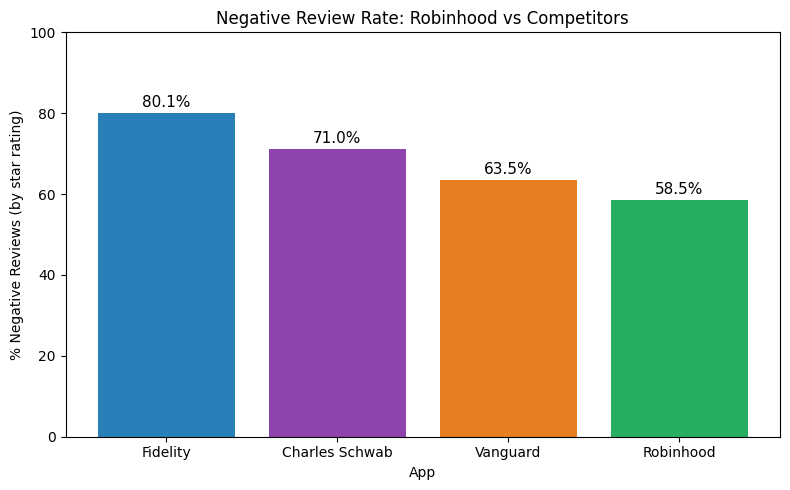

In [ ]:
# Negative review rate comparison
neg_pct = {}

for name, df in competitor_dfs.items():
    if not df.empty:
        neg_pct[name] = (df['sentiment'] == 'negative').mean() * 100

# Add Robinhood so all four apps appear side by side
neg_pct['Robinhood'] = (combined_df['sentiment'] == 'negative').mean() * 100

colors = ['#2980B9', '#8E44AD', '#E67E22', '#27AE60']
plt.figure(figsize=(8, 5))
plt.bar(list(neg_pct.keys()), list(neg_pct.values()), color=colors)
plt.ylabel('% Negative Reviews (by star rating)')
plt.xlabel('App')
plt.title('Negative Review Rate: Robinhood vs Competitors')
plt.ylim(0, 100)
for i, (k, v) in enumerate(neg_pct.items()):
    plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
# plt.savefig('competitor_neg_rate.png', bbox_inches='tight')
plt.show()

In [60]:
import pickle
import json

# Save all pipeline components for streamlit
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('lsa_pipeline.pkl', 'wb') as f:
    pickle.dump(lsa, f)

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(km_final, f)

with open('logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)


metadata = {
    'cluster_label_map': cluster_label_map,
    'sentiment_classes': list(lr.classes_),
    'n_features': X.shape[1],
    'n_reviews_trained_on': len(combined_df),
    'tfidf_vocab_size': len(tfidf.get_feature_names_out())
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: tfidf_vectorizer.pkl')
print('Saved: lsa_pipeline.pkl')
print('Saved: kmeans_model.pkl')
print('Saved: logistic_regression.pkl')
print('Saved: svd_model.pkl')
print('Saved: model_metadata.json')

Saved: tfidf_vectorizer.pkl
Saved: lsa_pipeline.pkl
Saved: kmeans_model.pkl
Saved: logistic_regression.pkl
Saved: svd_model.pkl
Saved: model_metadata.json


#Tests

In [73]:
import pytest
import numpy as np

# Helper functions for tests (assuming these are defined in the main notebook)
# You might need to import them explicitly if this code were in a separate file
# For this notebook context, they are globally available.

def test_get_sentiment():
    assert get_sentiment(1) == 'negative'
    assert get_sentiment(2) == 'negative'
    assert get_sentiment(3) == 'neutral'
    assert get_sentiment(4) == 'positive'
    assert get_sentiment(5) == 'positive'

def test_clean_text():
    assert not any(c.isdigit() for c in clean_text('lost $500 in 3 days'))
    assert clean_text('GREAT APP') == clean_text('great app')
    assert '!' not in clean_text('terrible!')
    assert '  ' not in clean_text('way   too   many   spaces')

def test_tfidf_matrix_shape():
    assert X.shape[0] == len(combined_df), 'row count mismatch'
    assert X.shape[1] > 0, 'no features'
    assert X.min() >= 0, 'negative TF-IDF values'

def test_lsa_shape_and_normalization():
    assert X_reduced.shape == (len(combined_df), 20)
    norms = np.linalg.norm(X_reduced, axis=1)
    # Filter out rows where the norm is 0 (from initially empty TF-IDF vectors)
    non_zero_norms = norms[norms != 0]
    # Then assert that the remaining norms are close to 1
    assert np.allclose(non_zero_norms, 1.0, atol=1e-2)

def test_kmeans_cluster_labels():
    assert len(cluster_labels_arr) == len(neg_df)
    assert set(cluster_labels_arr).issubset(set(range(5)))

def test_lr_predictions():
    valid_classes = {'negative', 'neutral', 'positive'}
    assert all(p in valid_classes for p in lr_preds)


In [74]:
# To run these tests directly in Colab (for demonstration):
# !pip install pytest # Uncomment if pytest is not installed
# pytest.main([__file__]) # This would typically be run from the command line
# As these are defined in a notebook, we'll call them directly for now.

print("Running tests...")

test_get_sentiment()
print("PASS  get_sentiment()")

test_clean_text()
print("PASS  clean_text()")

test_tfidf_matrix_shape()
print("PASS  TF-IDF matrix")

test_lsa_shape_and_normalization()
print("PASS  LSA (shape + unit norm)")

test_kmeans_cluster_labels()
print("PASS  K-Means labels")

test_lr_predictions()
print("PASS  LR predictions")

print("All tests passed!")


Running tests...
PASS  get_sentiment()
PASS  clean_text()
PASS  TF-IDF matrix
PASS  LSA (shape + unit norm)
PASS  K-Means labels
PASS  LR predictions
All tests passed!
